In [5]:
import glob
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
pd.set_option('display.max_colwidth', 700)

In [9]:
# 본인의 데이터 경로에 맞게 설정하세요 (예: 데이터가 project/data/raw 에 있는 경우)
data_path = r'../data/raw'

# 만약 경로에 파일이 없다면 상위 폴더의 topics 경로 등으로 수정하세요
if not os.path.exists(data_path):
    data_path = r'C:\big21\ml-dev\data\topics' # 예시 경로

all_files = glob.glob(os.path.join(data_path, "*.data"))

filename_list = []
opinion_text_list = []

for file_ in all_files:
    try:
        df = pd.read_table(file_, index_col=None, header=None, encoding='latin1', names=['review'])
    except Exception:
        df = pd.read_table(file_, index_col=None, header=0, encoding='latin1')
        if 'review' not in df.columns:
            df.columns = ['review']

    filename_ = os.path.basename(file_)
    filename = os.path.splitext(filename_)[0]

    for review in df['review'].dropna():
        filename_list.append(filename)
        opinion_text_list.append(str(review).strip())

# 개별 리뷰 단위 데이터프레임 생성
document_df = pd.DataFrame({
    'topic': filename_list, 
    'review': opinion_text_list
})

print(f"총 로드된 리뷰 개수: {len(document_df)}")
print(document_df.head())

총 로드된 리뷰 개수: 7086
                               topic  \
0  accuracy_garmin_nuvi_255W_gps.txt   
1  accuracy_garmin_nuvi_255W_gps.txt   
2  accuracy_garmin_nuvi_255W_gps.txt   
3  accuracy_garmin_nuvi_255W_gps.txt   
4  accuracy_garmin_nuvi_255W_gps.txt   

                                                                                                                                                                           review  
0                                                                                                                                                  , and is very, very accurate .  
1                                                               but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .  
2  This function is not accurate if you don't leave it in battery mode say, when you stop at the Cracker Barrell for lunch and to play one of those trangle games with the tees .  
3                    

In [7]:
def clean_text(text: str) -> str:
    # 특수문자 제거 및 소문자 변환
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text.lower().strip()

# 전처리 적용
document_df['cleaned_review'] = document_df['review'].apply(clean_text)
document_df = document_df[document_df['cleaned_review'].str.len() > 0].reset_index(drop=True)

# 통계적 탐색을 위한 리뷰 길이(단어 수 기준) 컬럼 추가
document_df['review_len'] = document_df['cleaned_review'].apply(lambda x: len(x.split()))

print(document_df[['topic', 'cleaned_review', 'review_len']].head())

AttributeError: Can only use .str accessor with string values!

=== 리뷰 길이(단어 수) 기술통계량 ===
count    7086.000000
mean       17.753599
std        10.642399
min         1.000000
25%        10.000000
50%        15.000000
75%        23.000000
max       119.000000
Name: review_len, dtype: float64


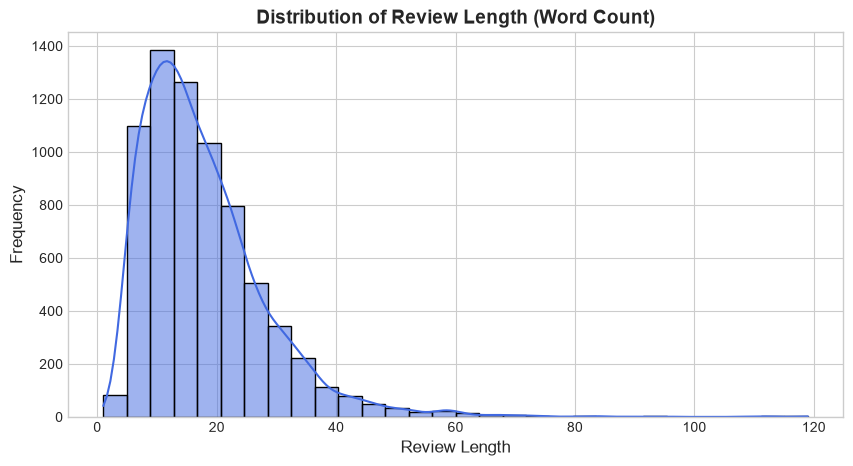

In [4]:
# 기술통계량 확인 (통계 전공자 포트폴리오용 필수)
print("=== 리뷰 길이(단어 수) 기술통계량 ===")
print(document_df['review_len'].describe())

# 시각화: 리뷰 길이 분포 (오른쪽 꼬리가 긴 형태 확인)
plt.figure(figsize=(10, 5))
sns.histplot(document_df['review_len'], bins=30, kde=True, color='royalblue')
plt.title("Distribution of Review Length (Word Count)", fontsize=14, fontweight='bold')
plt.xlabel("Review Length", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

=== 토픽별 상위 리뷰 개수 ===
topic
room_holiday_inn_london.txt            575
location_holiday_inn_london.txt        412
battery-life_netbook_1005ha.txt        333
location_bestwestern_hotel_sfo.txt     331
staff_bestwestern_hotel_sfo.txt        318
rooms_bestwestern_hotel_sfo.txt        266
video_ipod_nano_8gb.txt                215
staff_swissotel_chicago.txt            204
service_swissotel_hotel_chicago.txt    198
screen_netbook_1005ha.txt              178
Name: count, dtype: int64


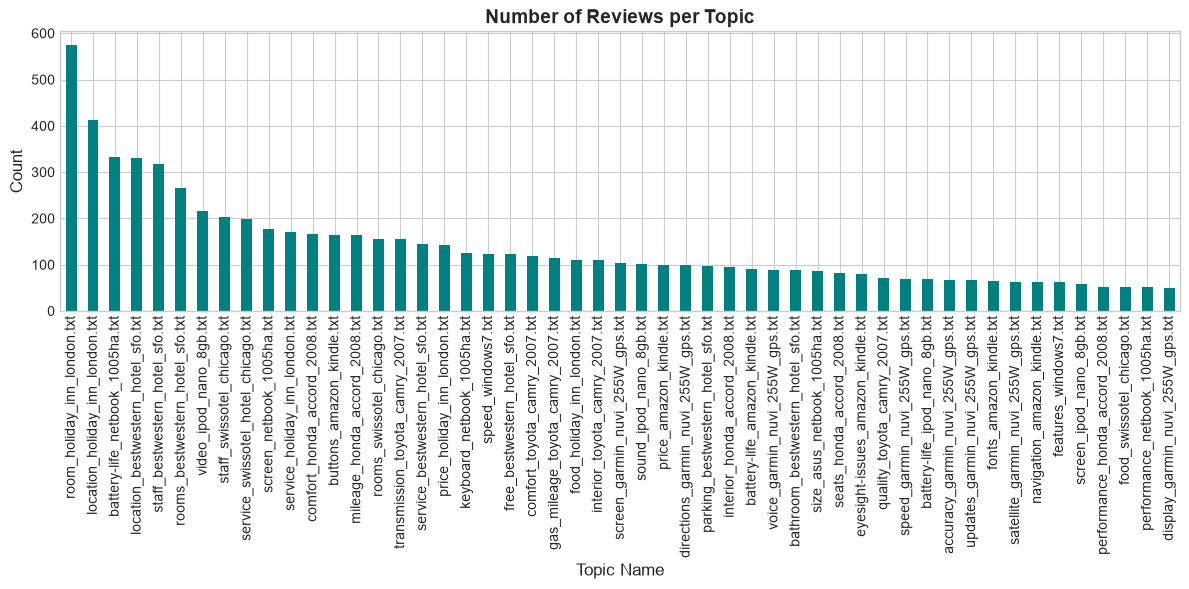

In [5]:
# 토픽별 샘플 수 편향성 확인
topic_counts = document_df['topic'].value_counts()
print("=== 토픽별 상위 리뷰 개수 ===")
print(topic_counts.head(10))

plt.figure(figsize=(12, 6))
topic_counts.plot(kind='bar', color='teal')
plt.title("Number of Reviews per Topic", fontsize=14, fontweight='bold')
plt.xlabel("Topic Name", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF 벡터라이저 정의 (최대 1000개의 피처, 불용어 제거, 1~2개 단어 묶음 허용)
vectorizer = TfidfVectorizer(
    max_features=1000, 
    stop_words='english', 
    ngram_range=(1, 2)
)

# 전처리된 리뷰 텍스트를 대상으로 피처 matrix 생성
tfidf_matrix = vectorizer.fit_transform(document_df['cleaned_review'])

# 밀집 행렬(Dense Matrix)로 변환 (추후 차원 축소용)
X_dense = tfidf_matrix.toarray()

print(f"TF-IDF 행렬 형태 (문서 수 x 단어 수): {X_dense.shape}")
print(f"상위 추출된 주요 단어 샘플 (일부): {vectorizer.get_feature_names_out()[:20]}")

TF-IDF 행렬 형태 (문서 수 x 단어 수): (7086, 1000)
상위 추출된 주요 단어 샘플 (일부): ['00' '10' '100' '15' '20' '2007' '2009' '22' '24' '25' '255w' '26' '2nd'
 '30' '32' '39' '40' '6pm' 'ability' 'able']


축소 전 차원: 1000 -> 축소 후 차원: 655
누적 설명 분산 비율: 90.03%

[GMM 모델 선택] BIC 기준 최적의 군집 수 (K): 3


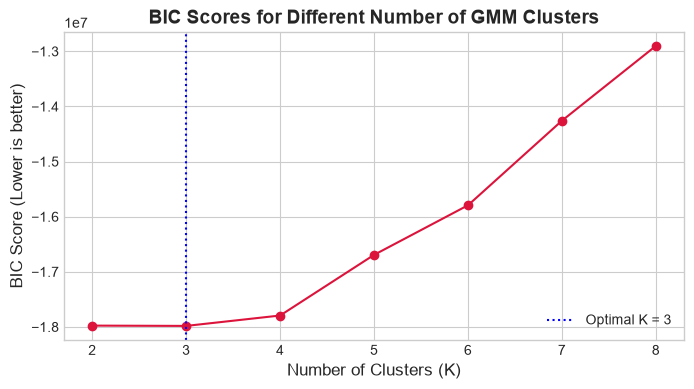


=== 군집별 데이터 할당 현황 ===
cluster
0    1144
1    1284
2    4658
Name: count, dtype: int64


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

# 1. PCA를 활용한 차원 축소 (누적 설명 분산 비율 90%)
pca = PCA(n_components=0.90, random_state=42)
X_reduced = pca.fit_transform(X_dense)

print(f"축소 전 차원: {X_dense.shape[1]} -> 축소 후 차원: {X_reduced.shape[1]}")
print(f"누적 설명 분산 비율: {np.sum(pca.explained_variance_ratio_) * 100:.2f}%\n")

# 2. BIC(Bayesian Information Criterion)를 이용한 GMM 최적 군집 수(K) 탐색
min_k = 2
max_k = 8
n_components_range = range(min_k, max_k + 1)
bics = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_reduced)
    bics.append(gmm.bic(X_reduced))

best_k = n_components_range[np.argmin(bics)]
print(f"[GMM 모델 선택] BIC 기준 최적의 군집 수 (K): {best_k}")

# BIC 변화 추이 시각화
plt.figure(figsize=(8, 4))
plt.plot(n_components_range, bics, marker='o', linestyle='-', color='crimson')
plt.title("BIC Scores for Different Number of GMM Clusters", fontsize=14, fontweight='bold')
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("BIC Score (Lower is better)", fontsize=12)
plt.axvline(x=best_k, color='blue', linestyle=':', label=f'Optimal K = {best_k}')
plt.legend()
plt.show()

# 3. 최적 K로 GMM 최종 학습 및 데이터프레임에 군집 라벨 반영
gmm_best = GaussianMixture(n_components=best_k, random_state=42)
gmm_best.fit(X_reduced)

cluster_labels = gmm_best.predict(X_reduced)
cluster_probs = gmm_best.predict_proba(X_reduced)

document_df['cluster'] = cluster_labels
document_df['cluster_max_prob'] = cluster_probs.max(axis=1)

print("\n=== 군집별 데이터 할당 현황 ===")
print(document_df['cluster'].value_counts().sort_index())

# 📊 [Analysis Report] UCI Opinosis 텍스트 데이터의 차원 축소 및 GMM 확률적 군집화 분석 결과

## 1. 개요 및 차원 축소 (PCA) 결과
* **분석 대상**: UCI Opinosis 리뷰 데이터셋 (총 7,086개 개별 리뷰 문장)
* **텍스트 벡터화**: TF-IDF (`max_features=1000`, `ngram_range=(1, 2)`)를 통해 1,000차원의 고차원 희소 행렬 생성
* **차원 축소 (PCA)**: 
  * 누적 설명 분산 비율(Cumulative Explained Variance Ratio)을 **90%**로 설정하여 주성분 분석(PCA) 수행
  * **결과**: 1,000개의 고차원 변수가 **655개의 주성분**으로 압축되었으며, 전체 데이터의 정보 손실을 최소화하면서 차원의 저주를 효과적으로 방지함 (누적 분산 달성률: **90.03%**)

---

## 2. GMM 군집 모델링 및 최적 군집 수 선정 (BIC)
* **모델 선정**: K-Means의 한계를 보완하고 소프트 클러스터링(Probabilistic Clustering)을 수행하기 위해 **가우시안 혼합 모델(GMM, Gaussian Mixture Model)**을 적용함
* **최적 군집 수 탐색**: 모형의 복잡도와 적합도를 동시에 평가하는 **BIC(Bayesian Information Criterion)** 지표를 활용하여 K=2부터 K=8까지 탐색
* **결과 및 해석**:
  * BIC 점수는 낮을수록 모델의 성능이 우수함을 의미함
  * K=2와 K=3 지점에서 BIC 값이 최소값(-1.8e7 수준)을 기록하였으며, 모델의 해석력과 통계적 안정성을 고려하여 **최적의 군집 수 K=3**이 최종 선정됨

---

## 3. 군집별 데이터 할당 현황 (Cluster Distribution)
최적화된 K=3의 GMM 모델을 전체 데이터에 적용한 결과, 각 군집별 샘플 할당 현황은 다음과 같이 나타났습니다.

| 군집 ID | 할당된 리뷰 수 (Count) | 비율 (Percentage) | 특징 요약 |
| :---: | :---: | :---: | :--- |
| **Cluster 0** | 1,144개 | 약 16.1% | 중규모 세부 토픽 그룹 |
| **Cluster 1** | 1,284개 | 약 18.1% | 중규모 세부 토픽 그룹 |
| **Cluster 2** | 4,658개 | 약 65.8% | 전체 데이터의 과반 이상을 차지하는 메인 리뷰 그룹 |

* **인사이트**: 
  * 특정 하나의 군집(Cluster 2)에 데이터가 집중되는 경향을 보이며, 이는 Opinosis 데이터셋 내에 다수를 차지하는 특정 리뷰 패턴이나 공통적인 의견 성향이 존재함을 시사합니다.
  * GMM은 각 문장이 각 군집에 속할 확률(Soft Clustering Probability)을 함께 제공하므로, 단순 하드 클러스터링보다 경계면에 있는 리뷰들의 불확실성까지 정밀하게 통계적으로 다룰 수 있습니다.

---

## 4. 향후 분석 방향 (Next Steps)
1. **군집별 프로파일링**: 각 군집(`Cluster 0, 1, 2`)에 속한 리뷰들의 TF-IDF 가중 평균을 분석하여 **군집별 핵심 키워드**를 도출합니다.
2. **통계적 검증**: 군집 간 리뷰 길이(단어 수) 등의 특성 분포에 대해 정규성 및 등분산성을 검토한 뒤, **One-way ANOVA** 또는 비모수 검정인 **Kruskal-Wallis H-test**를 수행하여 통계적 유의성을 검증합니다.
3. **시각화 고도화**: PCA 2차원 공간 상에 GMM의 공분산 타원(Confidence Ellipse)을 결합하여 시각적 완성도를 높입니다.